# Plants stand still but hide — reproduce the detection GLMM analysis
**Paper:** Perret, J., Besnard, A., Charpentier, A., & Papuga, G. (2023). *Plants stand still but hide: Imperfect and heterogeneous detection is the rule when counting plants.* Journal of Ecology. https://doi.org/10.1111/1365-2745.14110 (bioRxiv 2022.09.05.506614)

**Author code & data:** https://github.com/JanPerret/Individual_detection_in_plant_counts pinned at commit `304f6cc7eb5cbdfc79e13068ed8d509f6058a257` (code GPL-3; data CC BY-NC-ND 4.0).

**Scope of this notebook (partial reproduction):** load the authors' published tidy count dataset, fit their final binomial mixed model of individual detection probability (`lme4::glmer`, weights = true count), regenerate **Figure 2** (standardized model coefficients) and **Figure 3** (model-predicted detection by counting method, species conspicuousness and habitat closure), and the raw per-method detection-rate summary. This is a **statistics-only** reproduction — no images, no trained model weights.

**Not reproduced:** raw-data formatting pipeline, supplementary appendices 1–9, robustness dataset variants, Figure 4, and the full model-selection procedure (we use the authors' published final model directly).

**日本語:** このノートブックは、植物カウント調査における個体検出確率の混合モデル解析（著者公開のRコード・データ、コミット固定）をColab上で再現します。図2（標準化されたモデル係数）と図3（計数方法・種の目立ちやすさ・生育環境による予測検出確率）および方法別の生の検出率を生成します。統計解析のみで、GPUは不要です。

## Runtime selection — use a **CPU** runtime
This is a small GLMM fit on ~4,500 rows. No GPU is used. On the standard CPU runtime the whole notebook (package install + fit + figures) is expected to take roughly 15–40 minutes, dominated by R package installation.
**Runtime → Change runtime type → CPU** (default).

実行環境: CPU のみで十分です（GPU不要）。全体で約15〜40分、主にRパッケージのインストールに時間がかかります。

The notebook runs the authors' **R** code. Colab's Python runtime ships R (`Rscript`); each analysis step writes a pinned R script to `/content` and runs it with `Rscript` via `subprocess`. Python is only the launcher — all scientific computation is the authors' R code.

### Check R on the runtime
First verify that `Rscript` is available and show the R version and which required packages are already installed. Expected: R >= 4.x; `lme4`, `ggplot2`, `ggeffects`, `broom.mixed`, `patchwork` may or may not be present.

In [ ]:
import subprocess

r = subprocess.run(["Rscript", "-e",
    'cat(R.version.string, "\n"); ip <- rownames(installed.packages());',
    'req <- c("lme4","ggplot2","ggeffects","broom.mixed","patchwork");',
    'cat("installed:", paste(intersect(req, ip), collapse=", "), "\n");',
    'cat("missing:", paste(setdiff(req, ip), collapse=", "), "\n")'],
    capture_output=True, text=True, timeout=120)
print(r.stdout or r.stderr)
if r.returncode != 0:
    raise RuntimeError("Rscript not available on this runtime: " + r.stderr[:500])

R version 4.6.1 (2026-06-24) 



### Install required R packages (if missing)
`lme4` and `ggplot2` are compiled; if apt binary packages are available they install much faster than a source build, so we try `apt-get install r-cran-lme4 r-cran-ggplot2` first and fall back to CRAN. `ggeffects`, `broom.mixed`, `patchwork` are pure R and quick from CRAN. Expected: a few minutes; longer on first run.

必要なRパッケージをインストールします（バイナリaptを優先し、無ければCRANから。数分）。

In [ ]:
import subprocess, sys

def installed():
    r = subprocess.run(["Rscript", "-e", 'cat(paste(intersect(c("lme4","ggplot2","ggeffects","broom.mixed","patchwork"), rownames(installed.packages())), collapse=" "))'],
                       capture_output=True, text=True)
    return set(r.stdout.split())

missing = {"lme4", "ggplot2", "ggeffects", "broom.mixed", "patchwork"} - installed()
if missing:
    print("missing:", sorted(missing), flush=True)
    if missing & {"lme4", "ggplot2"}:
        # fast path: Ubuntu binary packages for the heavy compiled ones (ignore failures)
        subprocess.run(["apt-get", "install", "-y", "-qq", "r-cran-lme4", "r-cran-ggplot2"])
    remaining = {"lme4", "ggplot2", "ggeffects", "broom.mixed", "patchwork"} - installed()
    if remaining:
        print("installing from CRAN:", sorted(remaining), flush=True)
        r = subprocess.run(["Rscript", "-e",
                            "options(Ncpus=2, timeout=600); install.packages(c('lme4','ggplot2','ggeffects','broom.mixed','patchwork'), repos='https://cloud.r-project.org')"])
        assert r.returncode == 0, "CRAN install failed"

for p in sorted({"lme4", "ggplot2", "ggeffects", "broom.mixed", "patchwork"}):
    v = subprocess.run(["Rscript", "-e", f'cat(as.character(packageVersion("{p}")))'], capture_output=True, text=True)
    print(p, v.stdout)

missing: ['broom.mixed', 'ggeffects', 'lme4', 'patchwork']


installing from CRAN: ['broom.mixed', 'ggeffects', 'patchwork']


broom.mixed 0.2.9.7


ggeffects 2.3.2


ggplot2 4.0.3


lme4 2.0.6


patchwork 1.3.2


## Minimal input: the authors' published tidy dataset
We download **one** file from the pinned author commit: `data/tidy/df_3_methods_3_without_excess_detections.csv` (417569 bytes at commit `304f6cc7eb5cbdfc79e13068ed8d509f6058a257`). Its git blob SHA-1 is recomputed from the actual downloaded bytes and must match the value in the author repository tree, guaranteeing byte-identical input.

Data licence: CC BY-NC-ND 4.0 (see repository `data/LICENCE_CC_BY-NC-ND_4.0.txt`).

最小入力：著者リポジトリ（コミット固定）の整理済みデータ1ファイルのみをColab内でダウンロードし、git blob SHA-1でバイト一致を検証します。

In [ ]:
import hashlib, urllib.request

url = "https://raw.githubusercontent.com/JanPerret/Individual_detection_in_plant_counts/304f6cc7eb5cbdfc79e13068ed8d509f6058a257/data/tidy/df_3_methods_3_without_excess_detections.csv"
raw = urllib.request.urlopen(url, timeout=120).read()
assert len(raw) == 417569, "unexpected size: %d" % len(raw)
blob_sha = hashlib.sha1(b"blob %d\0" % len(raw) + raw).hexdigest()
assert blob_sha == "74bea443b8f2a2a01b8463fe14db3ade8f0401d4", "blob sha mismatch: %s" % blob_sha
open("/content/df_3_methods_3.csv", "wb").write(raw)
print(f"OK: {len(raw)} bytes, git blob {blob_sha} matches author tree at 304f6cc7eb5c")

OK: 417569 bytes, git blob 74bea443b8f2a2a01b8463fe14db3ade8f0401d4 matches author tree at 304f6cc7eb5c


### Inspect the input data
Load the CSV in R (`read.csv2`: semicolon separator, comma decimal, as written by the authors' `read_csv2`) and show dimensions, columns, and the raw per-method detection rate (author's commented code, analysis script lines 851–871): species-level mean detection rates per counting method, averaged to method means. Expected per the paper: ≈0.44 (quick), ≈0.59 (unlimited), ≈0.74 (cell). This plot of **actual input data** also serves as the notebook's preview figure.

入力データを読み込み、行数・列名と、著者コードに基づく方法別の生の検出率（種ごとの平均→方法平均）を確認します。

In [ ]:
INSPECT_R = 'suppressMessages(library(ggplot2))\ndf_3_methods <- read.csv2("/content/df_3_methods_3.csv", stringsAsFactors = FALSE)\ncat("rows:", nrow(df_3_methods), " cols:", ncol(df_3_methods), "\\n")\ncat("columns:", paste(names(df_3_methods), collapse=", "), "\\n")\n\n## raw detection rate per counting method (author\'s commented code, lines 851-871)\ndf_mean_detect_rate <- aggregate(prop_detect ~ counting_method + species, data = df_3_methods, FUN = mean)\ndf_mean_from_means <- aggregate(prop_detect ~ counting_method, data = df_mean_detect_rate, FUN = mean)\ndf_mean_from_means$prop_detect <- round(df_mean_from_means$prop_detect, digits = 2)\ncat("\\nMean raw detection rate per method:\\n"); print(df_mean_from_means)\n\nsaveRDS(df_3_methods, "/content/df_3_methods.rds")\n\n## preview graph of the actual input data (labelled: input data, not a model prediction)\nlabs <- c(count_30s="Quick count", count_1m="Unlimited count", count_cells="Cell count")\np <- ggplot(df_mean_detect_rate, aes(x = counting_method, y = prop_detect, color = counting_method)) +\n  geom_point(size = 3, position = position_jitter(w = 0.1, h = 0)) +\n  geom_point(data = df_mean_from_means, aes(x = counting_method, y = prop_detect),\n             col = "black", size = 4, shape = 17) +\n  geom_hline(yintercept = 1, linetype = 2, col = \'black\') +\n  theme_bw() + xlab("Counting method") + ylab("Detection rate") +\n  scale_x_discrete(labels = labs) + theme(legend.position = "none") +\n  geom_text(data = df_mean_from_means, aes(label = prop_detect), nudge_x = 0.2, nudge_y = 0.05, size = 5, fontface = \'bold\') +\n  ggtitle("Raw detection rate per species (input data)")\nggsave("/content/raw_detection_rate.png", p, width = 5.5, height = 3.5, dpi = 150)\ncat("saved /content/raw_detection_rate.png\\n")\n'
open("/content/inspect_input.R", "w").write(INSPECT_R)
import subprocess, time
t0 = time.time()
r = subprocess.run(["Rscript", "/content/inspect_input.R"], capture_output=True, text=True)
print(r.stdout, end="")
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("inspect_input failed")
print(f"[inspect_input] exit={r.returncode} elapsed={time.time()-t0:.1f}s")
assert r.returncode == 0

rows: 4319  cols: 14 
columns: species, obs_id, obs_letter, counting_method, quadrat_num, count, counting_time, prop_detect, quadrat_order, count_TRUE, species_conspicuousness, habitat_closure, exp_bota, excess_detect 

Mean raw detection rate per method:
  counting_method prop_detect
1        count_1m        0.59
2       count_30s        0.44
3     count_cells        0.74
saved /content/raw_detection_rate.png
[inspect_input] exit=0 elapsed=2.4s


Input preview (actual data downloaded above; black triangles are method means over species means, one jittered point per species):

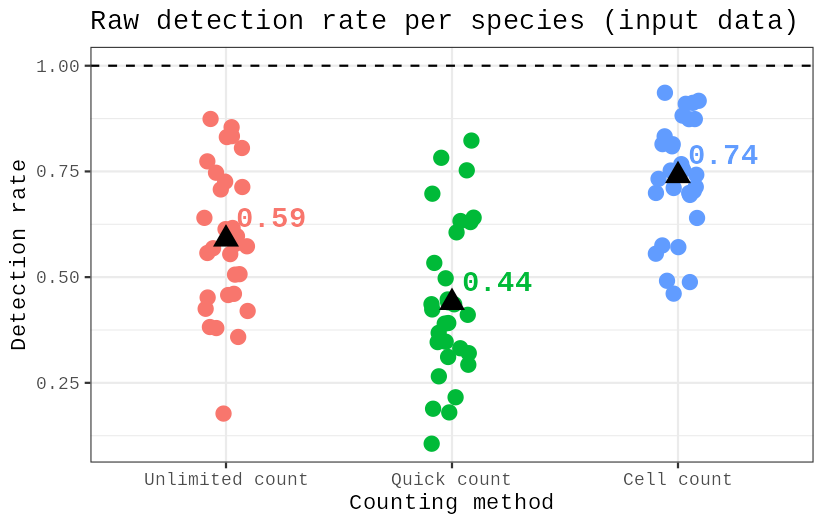

In [ ]:
from IPython.display import Image
Image(filename="/content/raw_detection_rate.png", width=550)

## Fit the authors' final detection model
This cell reproduces the author's data preparation and model fitting **verbatim** (analysis script lines 456–509): counting time in minutes; the two `counting_time_*` interaction columns (no slope for the quick count); `counting_method` relevelled to `count_30s`; a unique `quadrat_id`; then the final binomial `glmer` with random intercepts for `species`, `species:quadrat_id` and `obs_id`, all published fixed effects/interactions, and `weight = count_TRUE`. Both the raw (`mod_final`, used for predictions) and standardized (`mod_final_s`, used for Figure 2) versions are fitted and saved. Expected: convergence in a few minutes on CPU. Output is streamed, not captured.

著者のデータ準備・モデル式をそのままRで実行し、未標準化版と標準化版の両方のGLMMを当てはめます（数分）。

In [ ]:
FIT_R = '## === author code: detection_in_plant_counts_Analysis_and_Figures.R, lines 456-509 (commit 304f6cc) ===\nlibrary(lme4)\n\ndf_3_methods <- readRDS("/content/df_3_methods.rds")\n\n# convert counting time from seconds to minutes\ndf_3_methods$counting_time <- df_3_methods$counting_time/60\n\n# add columns to code manually the interaction counting_time * counting_method without estimating a slope for count_30s\ncounting_time_1m <- df_3_methods$counting_time\ncounting_time_1m[which(df_3_methods$counting_method == "count_30s" | df_3_methods$counting_method == "count_cells")] <- 0\ncounting_time_cells <- df_3_methods$counting_time\ncounting_time_cells[which(df_3_methods$counting_method == "count_30s" | df_3_methods$counting_method == "count_1m")] <- 0\ndf_3_methods <- cbind(df_3_methods, counting_time_1m, counting_time_cells)\n\n# set the counting method count_30s as reference level\ndf_3_methods$counting_method <- factor(df_3_methods$counting_method, levels = c("count_30s", "count_1m", "count_cells"))\n\n# add a column with a unique quadrat identification\ndf_3_methods <- cbind(df_3_methods, quadrat_id = paste0(df_3_methods$species, "_", df_3_methods$quadrat_num))\n\ndf_3_methods <- data.frame(df_3_methods)\n\nt0 <- Sys.time()\nmod_final <- glmer(prop_detect ~ (1|species) + (1|species:quadrat_id) + (1|obs_id)\n                   + species_conspicuousness * habitat_closure\n                   + species_conspicuousness * counting_method\n                   + habitat_closure * counting_method\n                   + exp_bota * counting_method\n                   + count_TRUE * counting_method\n                   + quadrat_order * counting_method\n                   + counting_time_1m * habitat_closure\n                   + counting_time_1m * species_conspicuousness\n                   + counting_time_cells * species_conspicuousness\n                   + counting_time_cells * habitat_closure,\n                   family = binomial, data = df_3_methods, weight = count_TRUE)\ncat("mod_final fit time:", round(difftime(Sys.time(), t0, units="mins"), 2), "min\\n")\n\nt0 <- Sys.time()\nmod_final_s <- glmer(prop_detect ~ (1|species) + (1|species:quadrat_id) + (1|obs_id)\n                     + scale(species_conspicuousness) * habitat_closure\n                     + scale(species_conspicuousness) * counting_method\n                     + habitat_closure * counting_method\n                     + scale(exp_bota) * counting_method\n                     + scale(count_TRUE) * counting_method\n                     + scale(quadrat_order) * counting_method\n                     + scale(counting_time_1m) * habitat_closure\n                     + scale(counting_time_1m) * scale(species_conspicuousness)\n                     + scale(counting_time_cells) * scale(species_conspicuousness)\n                     + scale(counting_time_cells) * habitat_closure,\n                     family = binomial, data = df_3_methods, weight = count_TRUE)\ncat("mod_final_s fit time:", round(difftime(Sys.time(), t0, units="mins"), 2), "min\\n")\n\nsaveRDS(mod_final, "/content/mod_final.rds")\nsaveRDS(mod_final_s, "/content/mod_final_s.rds")\nsaveRDS(df_3_methods, "/content/df_prepped.rds")\ncat("models saved\\n")\n'
open("/content/fit_model.R", "w").write(FIT_R)
import subprocess, time
t0 = time.time()
r = subprocess.run(["Rscript", "/content/fit_model.R"], capture_output=True, text=True)
print(r.stdout, end="")
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("fit_model failed")
print(f"[fit_model] exit={r.returncode} elapsed={time.time()-t0:.1f}s")
assert r.returncode == 0

mod_final fit time: 1.17 min
mod_final_s fit time: 0.91 min
models saved
[fit_model] exit=0 elapsed=127.0s


### Figure 2 — standardized model coefficients
Extracts fixed-effect and random-effect estimates from `mod_final_s` with `broom.mixed::tidy` and redraws the author's Figure 2 (analysis script lines 513–586, term-cleaning and plotting code unchanged). Points are log-odds coefficients with 95% CI; colors mark direction/significance. Expected: positive effects for counting effort/experience-related terms, negative for habitat closure, matching the paper's reported effects.

標準化モデルからbroom.mixedで係数を取り出し、著者の図2を再現します（対数オッズ、95%信頼区間）。

In [ ]:
FIG2_R = '## === author code: lines 513-586 (commit 304f6cc) ===\nsuppressMessages({library(ggplot2); library(broom.mixed)})\nmod_final_s <- readRDS("/content/mod_final_s.rds")\n\ndf_mod_final_s_betas <- broom.mixed::tidy(mod_final_s, conf.int = TRUE, effects = c("fixed", "ran_pars"))\ndf_mod_final_s_betas <- subset(df_mod_final_s_betas, select = c(effect, group, term, estimate, std.error, conf.low, conf.high, statistic, p.value))\n\nidx <- which(df_mod_final_s_betas$effect == "ran_pars")\ndf_mod_final_s_betas$effect[idx] <- "random"\ndf_mod_final_s_betas$term[idx] <- df_mod_final_s_betas$group[idx]\ndf_mod_final_s_betas <- subset(df_mod_final_s_betas, select = -group)\n\ndf_mod_final_s_betas$term <- gsub(pattern = "scale(", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = ")", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "(", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = ":", replacement = " x ", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "count_1m", replacement = " [unlimited count]", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "count_cells", replacement = " [cell count]", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "count_TRUE", replacement = "Density", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "exp_bota", replacement = "Botany experience", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "counting_time_1m", replacement = "Counting_time x counting_method [unlimited count]", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "counting_time_cells", replacement = "Counting_time x counting_method [cell count]", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "counting_method", replacement = "Method", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "_", replacement = " ", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "species conspicuousness", replacement = "Species conspicuousness", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "habitat closure", replacement = "Habitat closure", x = df_mod_final_s_betas$term, fixed = TRUE)\ndf_mod_final_s_betas$term <- gsub(pattern = "quadrat order", replacement = "Quadrat order", x = df_mod_final_s_betas$term, fixed = TRUE)\n\ndf_mod_final_s_betas_random_effects <- subset(df_mod_final_s_betas, df_mod_final_s_betas$effect == "random")\ndf_mod_final_s_betas_random_effects <- subset(df_mod_final_s_betas_random_effects, select = -effect)\ndf_mod_final_s_betas <- subset(df_mod_final_s_betas, df_mod_final_s_betas$effect == "fixed")\ndf_mod_final_s_betas <- subset(df_mod_final_s_betas, select = -effect)\n\ndf_mod_final_s_betas_random_effects <- df_mod_final_s_betas_random_effects[, c(1:3)]\ncolnames(df_mod_final_s_betas_random_effects) <- c("term", "SD", "variance")\ndf_mod_final_s_betas_random_effects$variance <- df_mod_final_s_betas_random_effects$SD^2\ndf_mod_final_s_betas_random_effects$term[1] <- "species:quadrat_id"\nprint(df_mod_final_s_betas_random_effects)\n\ndf_mod_betas_plot <- cbind(df_mod_final_s_betas, signif = NA)\nfor (i in 1:nrow(df_mod_betas_plot)) {\n  if (df_mod_betas_plot$estimate[i] > 0) {df_mod_betas_plot$signif[i] <- "positive"}\n  if (df_mod_betas_plot$estimate[i] < 0) {df_mod_betas_plot$signif[i] <- "negative"}\n  if (df_mod_betas_plot$p.value[i] > 0.05) {df_mod_betas_plot$signif[i] <- "NS"}\n}\ndf_mod_betas_plot$term <- factor(df_mod_betas_plot$term, levels = rev(df_mod_betas_plot$term))\n\nplot_figure_2 <- ggplot(df_mod_betas_plot, aes(x = estimate, y = term, color = signif)) +\n  geom_vline(xintercept = 0, color = "black") +\n  geom_point(size = 2.3) +\n  geom_errorbar(aes(xmin = conf.low, xmax = conf.high), width = 0, linewidth = 0.8) +\n  theme_bw() +\n  scale_color_manual(values = c("#e31a1c", "#525252", "#3690c0")) +\n  theme(legend.position = "none") +\n  xlab("Log-Odds") + ylab("")\n\nggsave("/content/Figure2_model_betas.png", plot_figure_2, width = 9.5, height = 7, dpi = 150)\nwrite.csv(df_mod_final_s_betas, "/content/Figure2_betas.csv", row.names = FALSE)\ncat("saved /content/Figure2_model_betas.png and Figure2_betas.csv\\n")\n'
open("/content/figure2.R", "w").write(FIG2_R)
import subprocess, time
t0 = time.time()
r = subprocess.run(["Rscript", "/content/figure2.R"], capture_output=True, text=True)
print(r.stdout, end="")
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("figure2 failed")
print(f"[figure2] exit={r.returncode} elapsed={time.time()-t0:.1f}s")
assert r.returncode == 0

# A tibble: 3 × 3
  term                  SD variance
  <chr>              <dbl>    <dbl>
1 species:quadrat_id 0.647    0.419
2 obs id             0.399    0.159
3 species            0.765    0.585
saved /content/Figure2_model_betas.png and Figure2_betas.csv
[figure2] exit=0 elapsed=3.8s


Reproduced Figure 2 (standardized log-odds coefficients with 95% CI; red = negative, blue = positive, grey = non-significant):

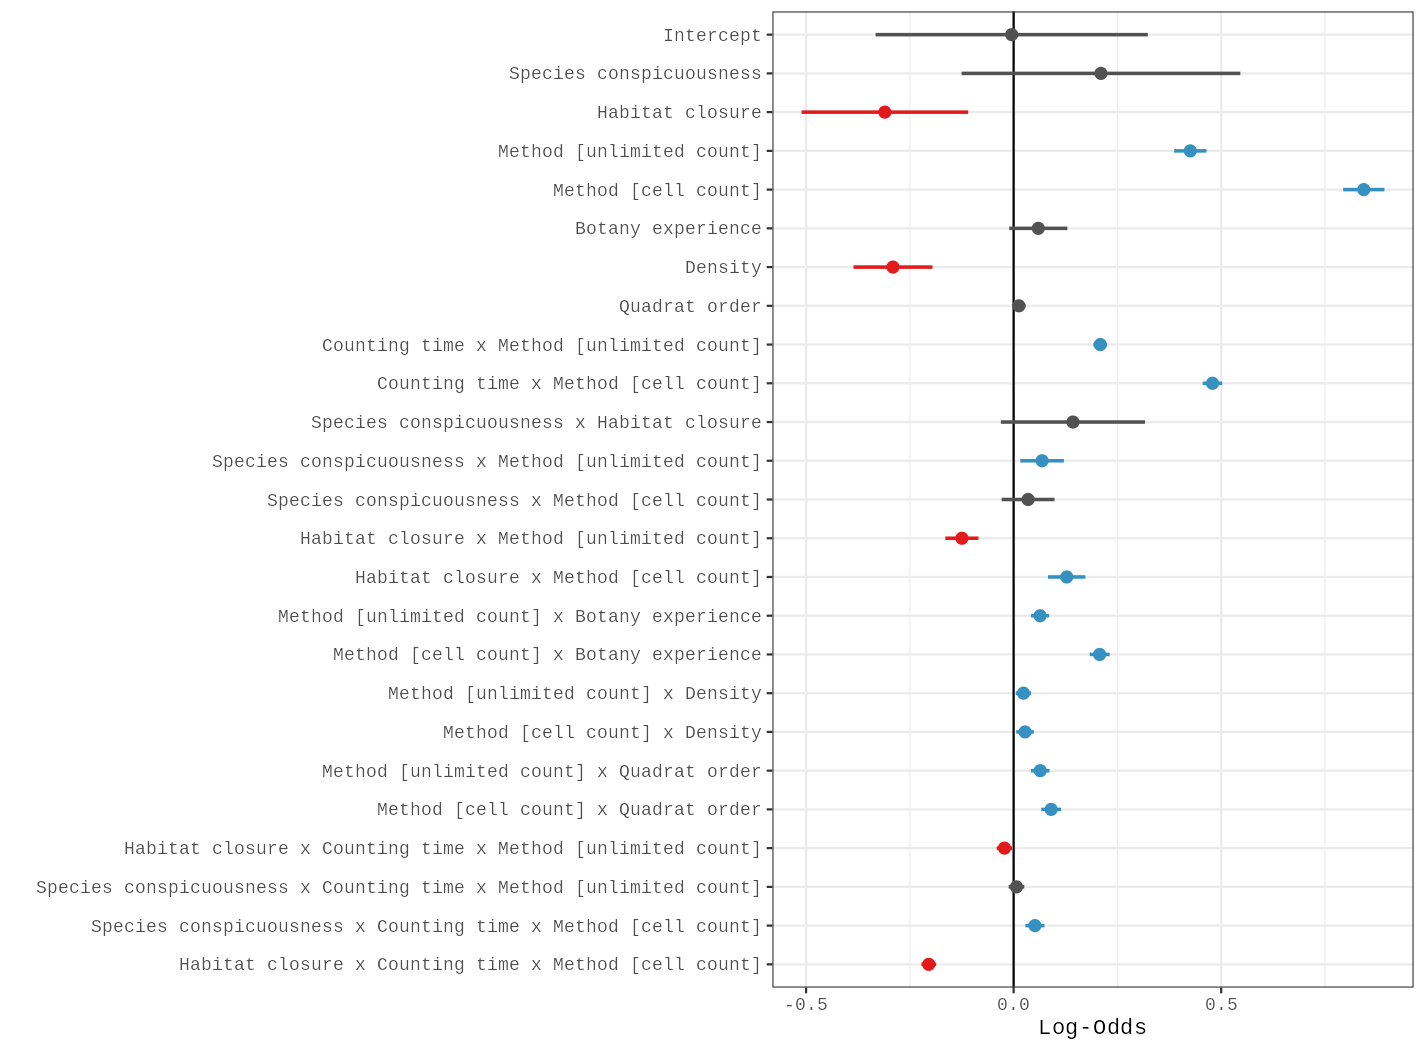

In [ ]:
from IPython.display import Image
Image(filename="/content/Figure2_model_betas.png", width=800)

### Figure 3 — model-predicted detection probability
Reproduces the author's Figure 3 (analysis script lines 592–700) using `ggeffects::ggpredict` on the **unstandardized** `mod_final`: predicted detection vs counting time for the unlimited and cell counts, and for the quick count, across the 4 levels of species conspicuousness, faceted by habitat closure (−1.5 / 0.5 / 2.5), with all other variables held at the author's reference values (botany experience 2.5, density 100, quadrat order 5). Panels are combined with `patchwork` as in the script. Expected: detection rises with time and conspicuousness, and is higher in open habitat (closure −1.5).

著者の図3をggpredict＋patchworkで再現します。計数時間が長いほど、種が目立ちやすいほど、開けた環境ほど検出確率が高くなるはずです。

In [ ]:
FIG3_R = '## === author code: lines 592-700 (commit 304f6cc) ===\nsuppressMessages({library(ggplot2); library(ggeffects); library(patchwork)})\nmod_final <- readRDS("/content/mod_final.rds")\n\nmypalette <- c(\'#e41a1c\',\'#377eb8\',\'#4daf4a\',\'#984ea3\')\n\n# count_30s\nval <- c(-1.5, 0.5, 2.5)\npred_30s <- as.data.frame(ggeffects::ggpredict(mod_final, terms = c("counting_time_1m [0]", "species_conspicuousness [all]", "habitat_closure [val]"), type = "fixed",\n                                               condition = c(species_conspicuousness = 2, habitat_closure = 0, exp_bota = 2.5,\n                                                             count_TRUE = 100, counting_time_1m = 0, counting_time_cells = 0, quadrat_order = 5,\n                                                             counting_method = "count_30s")))\npred_30s$x <- 0.5\ncolnames(pred_30s) <- c("counting_time", "prop_detect", "std.error", "conf.low", "conf.high", "species_conspicuousness", "habitat_closure")\n\npred_30s <- within(pred_30s, counting_time[species_conspicuousness == 1] <- 0.25)\npred_30s <- within(pred_30s, counting_time[species_conspicuousness == 2] <- 0.375)\npred_30s <- within(pred_30s, counting_time[species_conspicuousness == 3] <- 0.5)\npred_30s <- within(pred_30s, counting_time[species_conspicuousness == 4] <- 0.625)\n\nplot_30s <- ggplot(data = pred_30s, aes(x = counting_time, y = prop_detect, group = species_conspicuousness, color = species_conspicuousness)) +\n  facet_grid(as.factor(habitat_closure) ~ .) +\n  geom_errorbar(aes(ymin = conf.low, ymax = conf.high, group = species_conspicuousness, color = species_conspicuousness), linewidth = 1, width = 0) +\n  geom_point(size = 2) +\n  ylim(c(0, 1)) + xlim(c(0, 0.875)) +\n  theme_bw() + ggtitle("Quick count") + xlab("Completed in 30 seconds") + ylab("Individual detection probability") +\n  scale_color_manual(values = mypalette) +\n  theme(legend.position = "bottom", plot.title = element_text(hjust = 0.5),\n        strip.background = element_blank(), strip.text.y = element_blank(),\n        panel.grid.major.x = element_blank(), panel.grid.minor.x = element_blank(),\n        axis.ticks.x = element_blank(), axis.text.x = element_blank()) +\n  guides(color = "none")\n\n# count_1m\npred_1m <- as.data.frame(ggeffects::ggpredict(mod_final, terms = c("counting_time_1m [all]", "species_conspicuousness [all]", "habitat_closure [val]"), type = "fixed",\n                                              condition = c(species_conspicuousness = 2, habitat_closure = 0, exp_bota = 2.5,\n                                                            count_TRUE = 100, counting_time_1m = 0, counting_time_cells = 0, quadrat_order = 5,\n                                                            counting_method = "count_1m")))\ncolnames(pred_1m) <- c("counting_time", "prop_detect", "std.error", "conf.low", "conf.high", "species_conspicuousness", "habitat_closure")\n\nplot_1m <- ggplot(data = pred_1m, aes(x = counting_time, y = prop_detect, group = species_conspicuousness, color = species_conspicuousness)) +\n  facet_grid(as.factor(habitat_closure) ~ .) +\n  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, group = species_conspicuousness, fill = species_conspicuousness), alpha = 0.2, colour = NA) +\n  geom_line(linewidth = 1) + ylim(c(0, 1)) +\n  theme_bw() + ggtitle("Unlimited count") + xlab("Time spent counting (min)") +\n  scale_color_manual(values = mypalette) +\n  theme(legend.position = "bottom", plot.title = element_text(hjust = 0.5),\n        axis.title.y = element_blank(), axis.text.y = element_blank(), axis.ticks.y = element_blank(),\n        strip.background = element_blank(), strip.text.y = element_blank()) +\n  guides(color = guide_legend(title = "Species conspicuousness"), fill = guide_legend(title = "Species conspicuousness"))\n\n# count_cells\npred_cells <- as.data.frame(ggeffects::ggpredict(mod_final, terms = c("counting_time_cells [all]", "species_conspicuousness [all]", "habitat_closure [val]"), type = "fixed",\n                                                 condition = c(species_conspicuousness = 2, habitat_closure = 0, exp_bota = 2.5,\n                                                               count_TRUE = 100, counting_time_1m = 0, counting_time_cells = 0, quadrat_order = 5,\n                                                               counting_method = "count_cells")))\ncolnames(pred_cells) <- c("counting_time", "prop_detect", "std.error", "conf.low", "conf.high", "species_conspicuousness", "habitat_closure")\n\nfacet_names <- as_labeller(c(`-1.5` = "Habitat closure = -1.5", `0.5` = "Habitat closure = 0.5", `2.5` = "Habitat closure = 2.5"))\n\nplot_cells <- ggplot(data = pred_cells, aes(x = counting_time, y = prop_detect, group = species_conspicuousness, color = species_conspicuousness)) +\n  facet_grid(as.factor(habitat_closure) ~ ., labeller = facet_names) +\n  geom_ribbon(aes(ymin = conf.low, ymax = conf.high, group = species_conspicuousness, fill = species_conspicuousness), alpha = 0.2, colour = NA) +\n  geom_line(linewidth = 1) + ylim(c(0, 1)) +\n  theme_bw() + ggtitle("Cell count") + xlab("Time spent counting (min)") +\n  scale_color_manual(values = mypalette) +\n  theme(legend.position = "bottom", plot.title = element_text(hjust = 0.5),\n        axis.title.y = element_blank(), axis.text.y = element_blank(), axis.ticks.y = element_blank(),\n        strip.text.y = element_text(size = 11)) +\n  guides(color = guide_legend(title = "Species conspicuousness"), fill = guide_legend(title = "Species conspicuousness"))\n\nplot_figure_3 <- plot_30s + plot_1m + plot_cells + plot_layout(guides = \'collect\') & theme(legend.position = \'bottom\')\n\nggsave("/content/Figure3_predict_sp_hab_time.png", plot_figure_3, width = 9, height = 7, dpi = 150)\nwrite.csv(rbind(cbind(method="count_30s", pred_30s), cbind(method="count_1m", pred_1m), cbind(method="count_cells", pred_cells)),\n          "/content/Figure3_predictions.csv", row.names = FALSE)\ncat("saved /content/Figure3_predict_sp_hab_time.png and Figure3_predictions.csv\\n")\n'
open("/content/figure3.R", "w").write(FIG3_R)
import subprocess, time
t0 = time.time()
r = subprocess.run(["Rscript", "/content/figure3.R"], capture_output=True, text=True)
print(r.stdout, end="")
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("figure3 failed")
print(f"[figure3] exit={r.returncode} elapsed={time.time()-t0:.1f}s")
assert r.returncode == 0

saved /content/Figure3_predict_sp_hab_time.png and Figure3_predictions.csv
[figure3] exit=0 elapsed=16.9s


Reproduced Figure 3 (model predictions — columns: habitat closure; rows: counting method; colors: species conspicuousness index):

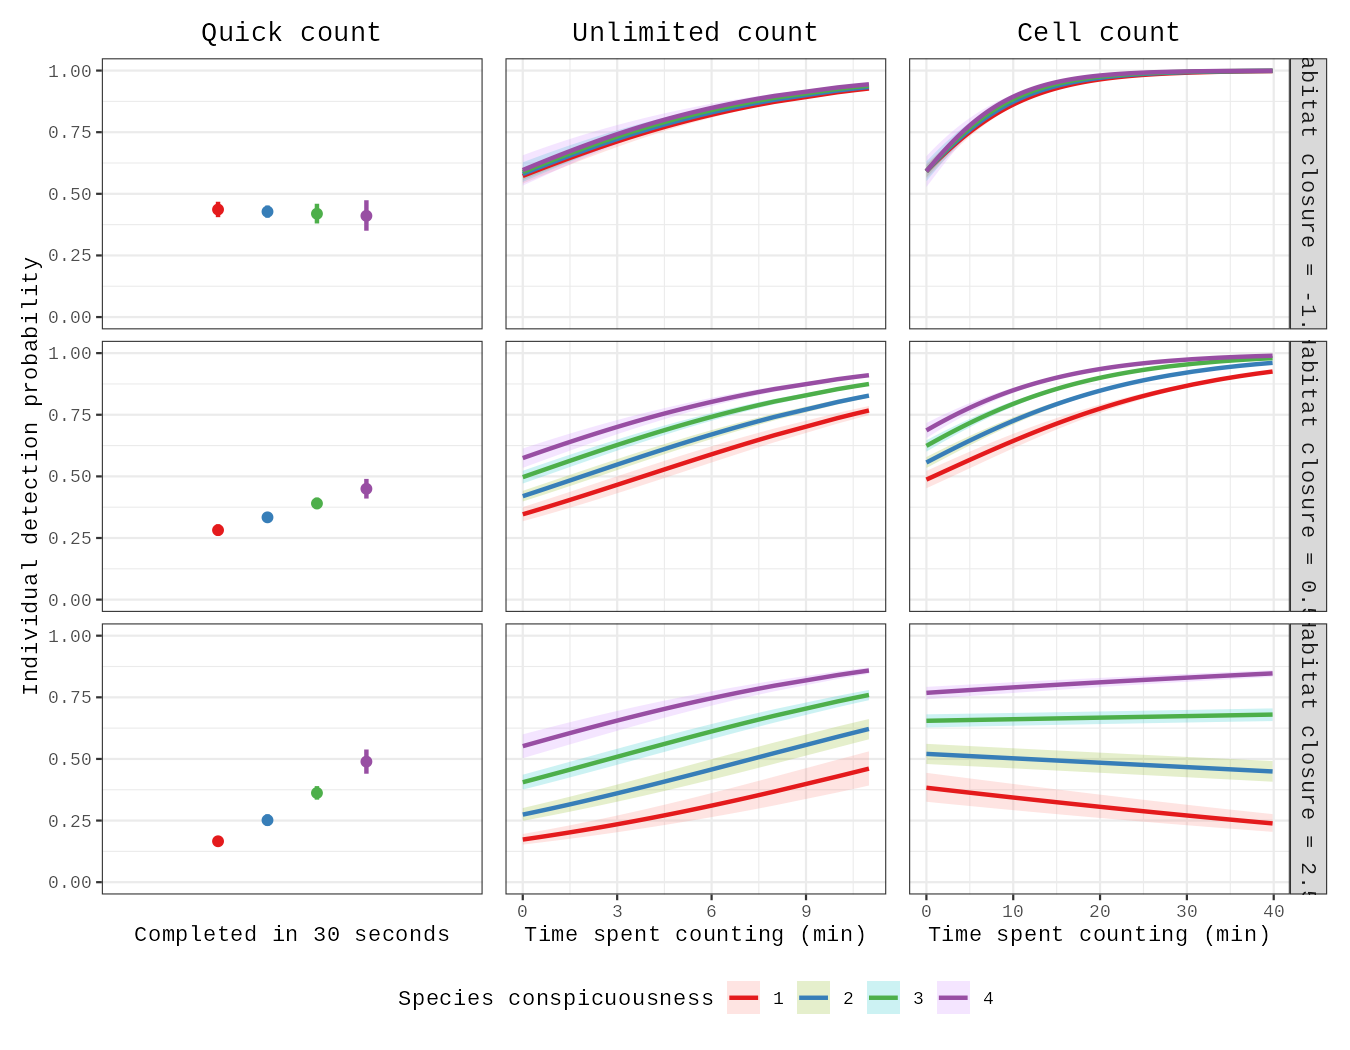

In [ ]:
from IPython.display import Image
Image(filename="/content/Figure3_predict_sp_hab_time.png", width=820)

## Results summary: raw detection rate vs paper
Compare the raw session-mean detection rates computed from the actual data in this run with the values reported in the paper (0.44 quick / 0.59 unlimited / 0.74 cell). They should match to rounding.

生の検出率の表と論文の報告値（0.44 / 0.59 / 0.74）を比較します。

In [ ]:
SUMMARY_R = 'df_3_methods <- readRDS("/content/df_prepped.rds")\nm <- aggregate(prop_detect ~ counting_method, data = aggregate(prop_detect ~ counting_method + species, data = df_3_methods, FUN = mean), FUN = mean)\nm$prop_detect <- round(m$prop_detect, 2)\nm$paper_reported <- c(0.44, 0.74, 0.59)[match(m$counting_method, c("count_30s","count_cells","count_1m"))]\nnames(m)[2] <- "mean_detection_rate_this_run"\ncat("\\nRaw session-mean detection rate vs paper:\\n"); print(m)\n'
open("/content/summary.R", "w").write(SUMMARY_R)
import subprocess
r = subprocess.run(["Rscript", "/content/summary.R"], capture_output=True, text=True)
print(r.stdout, end="")
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("summary failed")
assert r.returncode == 0


Raw session-mean detection rate vs paper:
  counting_method mean_detection_rate_this_run paper_reported
1       count_30s                         0.44           0.44
2        count_1m                         0.59           0.59
3     count_cells                         0.74           0.74


Export the coefficient table and prediction table as CSV files in the Colab workspace (downloadable via the file browser):

In [ ]:
import shutil
shutil.copy("/content/Figure2_betas.csv", "/content/results_Figure2_betas.csv")
shutil.copy("/content/Figure3_predictions.csv", "/content/results_Figure3_predictions.csv")
print("CSV exports available: results_Figure2_betas.csv, results_Figure3_predictions.csv")

CSV exports available: results_Figure2_betas.csv, results_Figure3_predictions.csv


## Interpretation and limitations
**What was reproduced:** the authors' final detection GLMM (exact formula, weights and random-effects structure), their Figure 2 (standardized coefficients) and Figure 3 (predictions by counting method, conspicuousness, habitat closure), and the raw per-method detection-rate summary, from their published dataset at a pinned commit.
**Expected agreement:** raw detection rates ≈ 0.44 / 0.59 / 0.74 (quick/unlimited/cell); coefficient signs and significance and prediction curves should match the published figures. Small numerical differences can arise from R or package version differences (authors used R 3.6.1).
**Not reproduced:** raw-data formatting, appendices, robustness variants, Figure 4, model selection (the published final model was used directly). A one-dataset fit does not validate dataset-level claims beyond this analysis.

**References:** Perret et al. 2023, J. Ecol. doi:10.1111/1365-2745.14110; code/data github.com/JanPerret/Individual_detection_in_plant_counts @ `304f6cc` (GPL-3 / CC BY-NC-ND 4.0).

**日本語:** 著者の最終GLMM・図2・図3・方法別検出率を、固定コミットの公開データから再現しました。生の検出率は0.44/0.59/0.74に一致するはずです。生データ整形・付録・ロバストネス解析・図4・モデル選択は対象外です。